In [1]:
import pandas as pd

from tabulate import tabulate

def print_df(df):
    if isinstance(df, pd.Series):
        df = df.to_frame()

    print(tabulate(df, headers='keys', tablefmt='psql', showindex=False))

In [3]:

vendas = pd.read_csv(r'C:\Users\lramo\OneDrive\Documentos\GitHub\python-estudos\file\docs\Contoso - Vendas - 2017.csv', sep=';', encoding='ISO-8859-1') # o sep é para especificar o separador do arquivo csv, nesse caso é o ponto e vírgula (;)

produtos = pd.read_csv(r'C:\Users\lramo\OneDrive\Documentos\GitHub\python-estudos\file\docs\Contoso - Cadastro Produtos.csv', sep=';', encoding='ISO-8859-1')


lojas = pd.read_csv(r'C:\Users\lramo\OneDrive\Documentos\GitHub\python-estudos\file\docs\Contoso - Lojas.csv', sep=';', encoding='ISO-8859-1')

clientes = pd.read_csv(r'C:\Users\lramo\OneDrive\Documentos\GitHub\python-estudos\file\docs\Contoso - Clientes.csv', sep=';', encoding='ISO-8859-1')

for df in [vendas, produtos, lojas, clientes]:
    df.columns = df.columns.str.replace('ÿ', '', regex=False)

# print_df(vendas.head())
# print_df(clientes.head())

# posso usar o drop para remover colunas

clientes = clientes.drop(columns=['Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10'])
#print_df(clientes.head())

# ou posso peggar as colunas

### pego os nomes das colunas se preciso
# print(produtos.columns.tolist()) pego as colunas do dataframe e transformo em uma lista
# print(clientes.columns.tolist())
# print(lojas.columns.tolist())

## junto as colunas que me interessam
clientes = clientes[['ID Cliente','E-mail']]
produtos = produtos[['ID Produto', 'Nome do Produto']]
lojas = lojas[['ID Loja', 'Nome da Loja']]

# print_df(produtos.head())
# print_df(lojas.head())

# agora vou juntar em outra tabela

vendas_df = vendas.merge(clientes, on='ID Cliente')
vendas_df = vendas_df.merge(produtos, on='ID Produto')
vendas_df = vendas_df.merge(lojas, on='ID Loja')

vendas_df = vendas_df.rename(columns={'E-mail': 'Email do Cliente'})

# print_df(vendas_df.head())



Email do Cliente
karen33@adventure-works.com      77
chloe77@adventure-works.com      74
julia43@adventure-works.com      69
destiny66@adventure-works.com    68
karen16@adventure-works.com      68
                                 ..
ckilfoyle88@yahoo.co.jp           1
pmcgaheylk@nbcnews.com            1
osaffleev@hao123.com              1
mtrimmill2d@abc.net.au            1
clifford8@adventure-works.com     1
Name: count, Length: 38907, dtype: int64

<Axes: xlabel='Email do Cliente'>

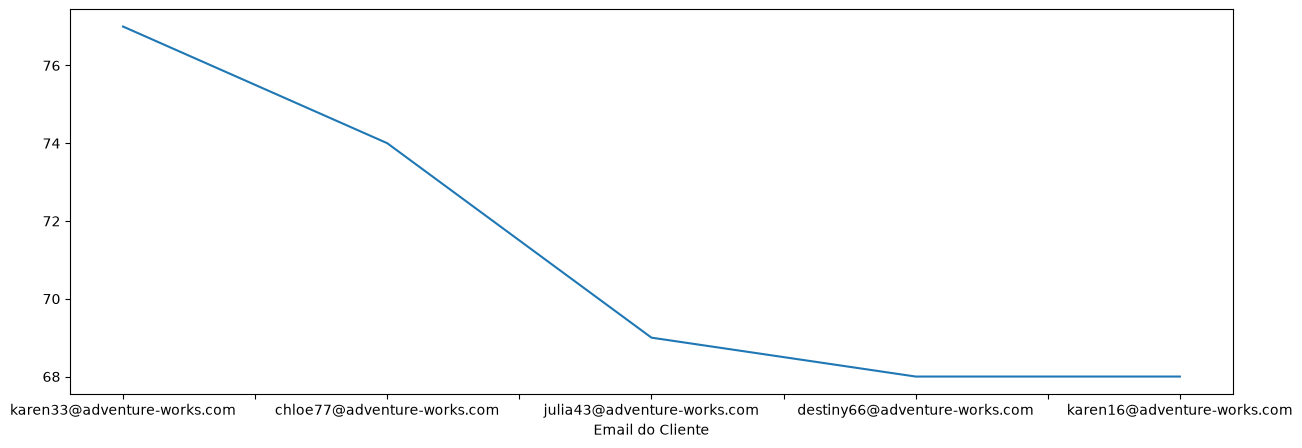

In [4]:
frequencia_clientes = vendas_df['Email do Cliente'].value_counts()
display(frequencia_clientes)
frequencia_clientes[:5].plot(figsize=(15, 5))

agrupar e pegar a loja que ,mais venderam

In [6]:
vendas_lojas = vendas_df.groupby('Nome da Loja').sum()
# quero pegar só qtd vendida, então faço isso:
vendas_lojas = vendas_lojas[['Quantidade Vendida']]
display(vendas_lojas.head())

,Quantidade Vendida
Nome da Loja,
Loja Contoso Albany,26353
Loja Contoso Alexandria,26247
Loja Contoso Amsterdam,28294
Loja Contoso Anchorage,27451
Loja Contoso Annapolis,26065


ordenar 

,Quantidade Vendida
Nome da Loja,
Loja Contoso Catalog,1029117
Loja Contoso North America Online,701961
Loja Contoso Europe Online,616845
Loja Contoso Asia Online,578458
Loja Contoso North America Reseller,520176
...,...
Loja Contoso Berlin,379
Loja Contoso Paterson,371
Loja Contoso Marseille,370


<Axes: xlabel='Nome da Loja'>

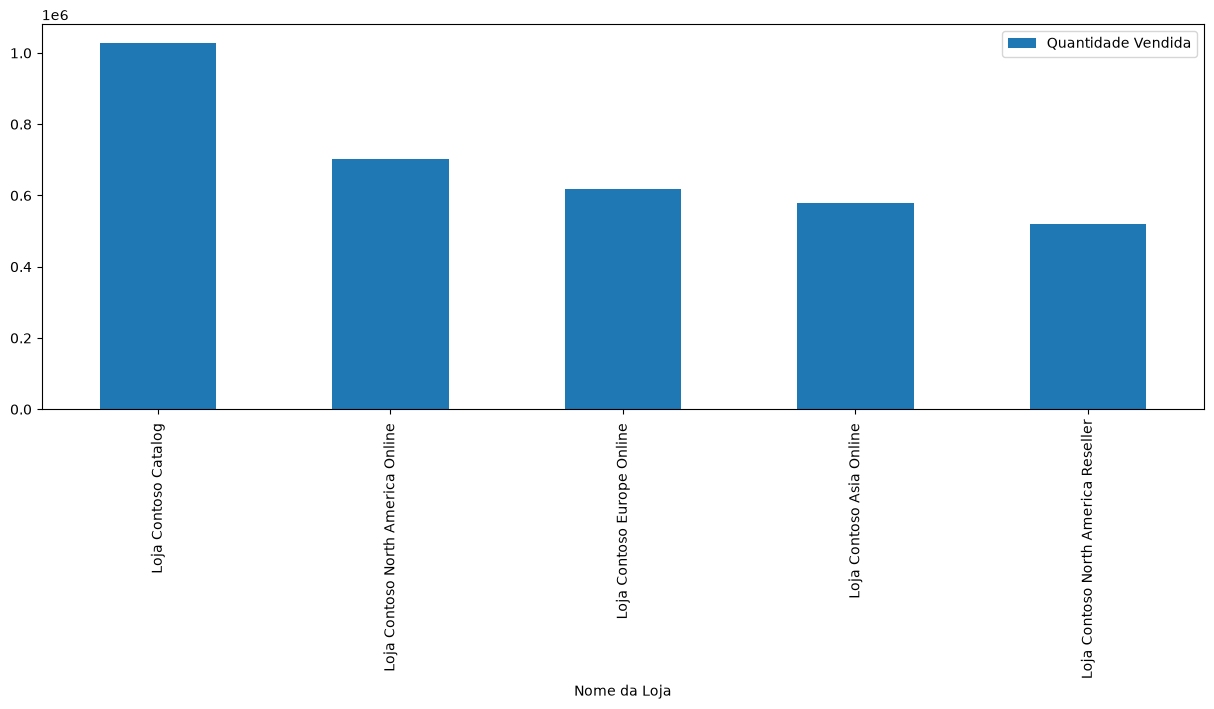

In [9]:
vendas_lojas = vendas_lojas.sort_values(by='Quantidade Vendida', ascending=False)
display(vendas_lojas)

vendas_lojas [:5].plot(kind='bar', figsize=(15, 5))

In [10]:
qtd_vendida_produtos = vendas_df.groupby('Nome do Produto').sum()[['Quantidade Vendida']]
qtd_vendida_produtos = qtd_vendida_produtos.sort_values(by='Quantidade Vendida', ascending=False)
display(qtd_vendida_produtos)

,Quantidade Vendida
Nome do Produto,
Cigarette Lighter Adapter for Contoso Phones E110 White,114300
Contoso Rubberized Skin BlackBerry E100 Black,113880
Contoso Rubberized Skin BlackBerry E100 White,113440
Contoso In-Line Coupler E180 Silver,113400
Contoso Rubberized Skin BlackBerry E100 Silver,113060
...,...
Contoso 4GB Portable MP3 Player M450 Black,136
SV 16xDVD E340 Black,124
Contoso 4GB Portable MP3 Player M450 Yellow,110


In [ ]:
# quantas vendas e devoluções global
qtd_vendidos =vendas_df['Quantidade Vendida'].sum()
qtd_devolvidos = vendas_df['Quantidade Devolvida'].sum()

percentual_devolvidos = (qtd_devolvidos / qtd_vendidos) * 100

print(f'Quantidade Vendida: {qtd_vendidos}')
print(f'Quantidade Devolvida: {qtd_devolvidos}')
print(f'Percentual Devolvido: {percentual_devolvidos:.2f}%')

Quantidade Vendida: 11851928
Quantidade Devolvida: 138931
Percentual Devolvido: 1.17%


In [19]:
# agora quero saber o percentual de devoluções por uma loja específica, por exemplo, a loja 'Contoso - Loja 1'

vendas_lojacontosoeuropeonline = vendas_df[vendas_df['ID Loja'] == 306]
qtd_vendidos_loja1 = vendas_lojacontosoeuropeonline['Quantidade Vendida'].sum()
qtd_devolvidos_loja1 = vendas_lojacontosoeuropeonline['Quantidade Devolvida'].sum()
percentual_devolvidos_loja1 = (qtd_devolvidos_loja1 / qtd_vendidos_loja1) * 100
display(f'Percentual Devolvido - Loja 1: {percentual_devolvidos_loja1:.2f}%')

'Percentual Devolvido - Loja 1: 1.33%'

se tiver 2 condições ou mais

In [21]:
loja306 = vendas_df['ID Loja'] == 306
qtd_devolvida_0= vendas_df['Quantidade Devolvida'] == 0
df_loja306sem_devolucao = vendas_df[loja306 & qtd_devolvida_0]
display(df_loja306sem_devolucao.head())

,Numero da Venda,Data da Venda,Data do Envio,ID Canal,ID Loja,ID Produto,ID Promocao,ID Cliente,Quantidade Vendida,Quantidade Devolvida,Email do Cliente,Nome do Produto,Nome da Loja
98,99,01/01/2017,03/01/2017,2,306,1269,10,26238,8,0,edward17@adventure-works.com,Contoso Carrying Case E312 Blue,Loja Contoso Europe Online
165,166,01/01/2017,02/01/2017,1,306,1107,10,7242,16,0,khanhard6r@taobao.com,"Contoso SLR Camera 35"" M358 Orange",Loja Contoso Europe Online
166,167,01/01/2017,05/01/2017,4,306,242,10,34277,16,0,marshall24@adventure-works.com,Contoso Home Theater System 7.1 Channel M1700 ...,Loja Contoso Europe Online
186,187,01/01/2017,06/01/2017,5,306,1479,10,23132,8,0,cynthia4@adventure-works.com,The Phone Company Smart phones Unlocked Intern...,Loja Contoso Europe Online
198,199,01/01/2017,03/01/2017,2,306,819,10,5363,4,0,svirgoea4@blogtalkradio.com,Contoso Laptop Cooling Hub notebook fan with 4...,Loja Contoso Europe Online
